# EDA — Brazilian Federal Highway Accidents (2017–2023)

This notebook prepares the dataset for severity classification.
The work follows a single pass: load, clean, single-variable analysis, multi-variable analysis, feature engineering and finishes with the cleaned dataframe ready for modelling.

**Research questions**

1. When it comes to predicting the multiclass severity of accidents using macro-F1 and per-class metrics, can tree-based classifiers (Decision Tree, Random Forest, XGBoost, LightGBM, and CatBoost) outperform a Logistic Regression baseline?
2. How does handling class imbalance (using random oversampling, random undersam-pling, SMOTE, ADASYN, SMOTE+Tomek, and class weighting) affect the performance of these models, and how do the main methods of class imbalance handling compare?
3. Which features are most important in predicting traffic accident severity?


---
## 1 · Setup

In [262]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Display ---
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.3f}'.format)

# --- Plot theme ---
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({
    'figure.figsize':   (10, 5),
    'figure.dpi':       100,
    'axes.titleweight': 'bold',
    'axes.titlesize':   13,
    'axes.titlepad':    12,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.size':        11,
})

# --- Palette ---
PALETTE = {
    'primary':  '#2E86AB',   # blue   — neutral / counts
    'accent':   '#E07A5F',   # coral  — highlight
    'danger':   '#C73E1D',   # red    — fatal / severe
    'warn':     '#F2A65A',   # amber  — injured
    'ok':       '#6BAA75',   # green  — without victims
    'muted':    '#9CA0A8',   # grey   — context
}
SEVERITY_COLORS = [PALETTE['ok'], PALETTE['warn'], PALETTE['danger']]

In [263]:
df = pd.read_csv('accidents_2017_to_2023_english.csv')
print(f"Loaded {df.shape[0]:,} rows × {df.shape[1]} columns")

Loaded 463,152 rows × 27 columns


---
## 2 · First look

Shape, types, and head

In [264]:
print("Shape :", df.shape, "\n")
print("Dtypes:")
print(df.dtypes.to_string())
print()
df.head()

Shape : (463152, 27) 

Dtypes:
inverse_data              str
week_day                  str
hour                      str
state                     str
road_id               float64
km                        str
city                      str
cause_of_accident         str
type_of_accident          str
victims_condition         str
weather_timestamp         str
road_direction            str
wheather_condition        str
road_type                 str
road_delineation          str
people                  int64
deaths                  int64
slightly_injured        int64
severely_injured        int64
uninjured               int64
ignored                 int64
total_injured           int64
vehicles_involved       int64
latitude              float64
longitude             float64
regional                  str
police_station            str



,inverse_data,week_day,hour,state,road_id,km,city,cause_of_accident,type_of_accident,victims_condition,weather_timestamp,road_direction,wheather_condition,road_type,road_delineation,people,deaths,slightly_injured,severely_injured,uninjured,ignored,total_injured,vehicles_involved,latitude,longitude,regional,police_station
0,2017-01-01,sunday,01:45:00,RS,116.000,"34,9",VACARIA,Mechanical loss/defect of vehicle,Rear-end collision,With injured victims,Night,Decreasing,Clear sky,Simple,Straight,6,0,4,0,2,0,4,2,-28.507,-50.941,SPRF-RS,DEL05-RS
1,2017-01-01,sunday,01:00:00,PR,376.000,636,TIJUCAS DO SUL,Incompatible velocity,Run-off-road,With dead victims,Night,Increasing,Drizzle,Double,Curve,2,1,0,0,1,0,0,2,-25.754,-49.127,SPRF-PR,DEL01-PR
2,2017-01-01,sunday,04:40:00,BA,101.000,65,ENTRE RIOS,Driver was sleeping,Head-on collision,With dead victims,Sunrise,Decreasing,Cloudy,Simple,Curve,5,1,1,1,2,0,2,2,-11.962,-38.095,SPRF-BA,DEL01-BA
3,2017-01-01,sunday,06:30:00,PA,316.000,"72,5",CASTANHAL,Driver's lack of attention to conveyance,Side impact collision,With dead victims,Sunrise,Decreasing,Clear sky,Simple,Straight,4,1,0,0,3,0,0,3,-1.290,-47.835,SPRF-PA,DEL01-PA
4,2017-01-01,sunday,09:00:00,GO,20.000,"220,5",POSSE,Road's defect,Collision with fixed object,With injured victims,Day,Decreasing,Clear sky,Simple,Temporary Detour,3,0,2,1,0,0,3,1,-14.142,-46.323,SPRF-DF,DEL02-DF


---
## 3 · Rename columns

The original names are inconsistent (mixed case, typos like `wheather_condition`).

In [265]:
df = df.rename(columns={
    'inverse_data':       'Date',
    'week_day':           'Day',
    'hour':               'Hour',
    'state':              'State',
    'road_id':            'Road_ID',
    'km':                 'Road_Km',
    'city':               'City',
    'cause_of_accident':  'Accident_Cause',
    'type_of_accident':   'Accident_Type',
    'victims_condition':  'Victims_Condition',
    'weather_timestamp':  'Day_Phase',
    'road_direction':     'Km_Direction',
    'wheather_condition': 'Weather_Condition',
    'road_type':          'Road_Type',
    'road_delineation':   'Road_Delineation',
    'people':             'People',
    'deaths':             'Deaths',
    'slightly_injured':   'Slightly_Injured',
    'severely_injured':   'Severely_Injured',
    'uninjured':          'Uninjured',
    'ignored':            'Ignored',
    'total_injured':      'Total_Injured',
    'vehicles_involved':  'Vehicles_Involved',
    'latitude':           'Latitude',
    'longitude':          'Longitude',
    'regional':           'Regional',
    'police_station':     'Police_Station',
})

df.head(3)

,Date,Day,Hour,State,Road_ID,Road_Km,City,Accident_Cause,Accident_Type,Victims_Condition,Day_Phase,Km_Direction,Weather_Condition,Road_Type,Road_Delineation,People,Deaths,Slightly_Injured,Severely_Injured,Uninjured,Ignored,Total_Injured,Vehicles_Involved,Latitude,Longitude,Regional,Police_Station
0,2017-01-01,sunday,01:45:00,RS,116.000,"34,9",VACARIA,Mechanical loss/defect of vehicle,Rear-end collision,With injured victims,Night,Decreasing,Clear sky,Simple,Straight,6,0,4,0,2,0,4,2,-28.507,-50.941,SPRF-RS,DEL05-RS
1,2017-01-01,sunday,01:00:00,PR,376.000,636,TIJUCAS DO SUL,Incompatible velocity,Run-off-road,With dead victims,Night,Increasing,Drizzle,Double,Curve,2,1,0,0,1,0,0,2,-25.754,-49.127,SPRF-PR,DEL01-PR
2,2017-01-01,sunday,04:40:00,BA,101.000,65,ENTRE RIOS,Driver was sleeping,Head-on collision,With dead victims,Sunrise,Decreasing,Cloudy,Simple,Curve,5,1,1,1,2,0,2,2,-11.962,-38.095,SPRF-BA,DEL01-BA


---
## 4 · Datetime & numeric conversions

Two cleanups, done together:

* `Date` + `Hour` => a single `Datetime` column (the originals are dropped).
* `Road_Km` uses European decimals — replace the comma so pandas sees a number.

In [266]:
# Combine Date + Hour, then drop the originals
df['Datetime'] = pd.to_datetime(df['Date'].astype(str) + ' ' + df['Hour'].astype(str))
df = df.drop(columns=['Date', 'Hour'])
print(df['Datetime'].dtype)
print(df['Datetime'].head())
# Move Datetime to the front for readability
df = df[['Datetime'] + [c for c in df.columns if c != 'Datetime']]

# Convert Road_Km (handling European decimal format)
df['Road_Km'] = pd.to_numeric(df['Road_Km'].str.replace(',', '.'), errors='coerce')

print(f"Datetime range: {df['Datetime'].min()}  =>  {df['Datetime'].max()}")
print(f"Road_Km dtype : {df['Road_Km'].dtype}")

datetime64[us]
0   2017-01-01 01:45:00
1   2017-01-01 01:00:00
2   2017-01-01 04:40:00
3   2017-01-01 06:30:00
4   2017-01-01 09:00:00
Name: Datetime, dtype: datetime64[us]
Datetime range: 2017-01-01 00:00:00  =>  2023-08-31 23:59:00
Road_Km dtype : float64


---
## 5 · Missing values

Three columns hold all of the missingness. Each gets a treatment that fits its meaning:

| Column | Strategy | Rationale |
|---|---|---|
| `Regional` | drop the rows | very few rows, can't be filled |
| `Police_Station` | fill with `"UNKNOWN"` | usable categorical placeholder |
| `Road_ID` / `Road_Km` | sentinel + flag column | the *fact that road info is missing* is itself a feature |

In [267]:
print("Nulls before treatment:")
print(df.isnull().sum()[df.isnull().sum() > 0].to_string())

Nulls before treatment:
Road_ID            990
Road_Km            990
Regional            10
Police_Station    1310


In [268]:
# 1) Drop rows missing Regional (very few)
df = df.dropna(subset=['Regional'])

# 2) Police_Station — flag, fill with placeholder
df['Missing_Police_Station'] = df['Police_Station'].isna()
df['Police_Station'] = df['Police_Station'].fillna('UNKNOWN')

# 3) Road_ID / Road_Km — flag + sentinel fill
df['Missing_Road_Data'] = df['Road_ID'].isna()
df['Road_ID']  = df['Road_ID'].fillna('NO_ROAD')
df['Road_Km']  = df['Road_Km'].fillna(-1)

remaining = df.isnull().sum().sum()
print(f"Remaining nulls: {remaining}")

Remaining nulls: 0


---
## 6 · Duplicate rows

Per supervisor feedback, exact duplicates will be dropped.

In [269]:
dups = df.duplicated().sum()
print(f"Exact duplicate rows: {dups}")

if dups:
    display(df[df.duplicated(keep=False)])

before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"\nDropped {before - len(df)} rows  =>  {len(df):,} remaining")

Exact duplicate rows: 9


,Datetime,Day,State,Road_ID,Road_Km,City,Accident_Cause,Accident_Type,Victims_Condition,Day_Phase,Km_Direction,Weather_Condition,Road_Type,Road_Delineation,People,Deaths,Slightly_Injured,Severely_Injured,Uninjured,Ignored,Total_Injured,Vehicles_Involved,Latitude,Longitude,Regional,Police_Station,Missing_Police_Station,Missing_Road_Data
19243,2017-10-20 14:25:00,friday,SC,282.000,483.900,FAXINAL DOS GUEDES,Disrespect of safe distance from the next car,Rear-end collision,Without victims,Day,Increasing,Sunny,Simple,Not Reported,2,0,0,0,2,0,0,2,-26.857,-52.246,SPRF-SC,DEL07-SC,False,False
75470,2017-10-20 14:25:00,friday,SC,282.000,483.900,FAXINAL DOS GUEDES,Disrespect of safe distance from the next car,Rear-end collision,Without victims,Day,Increasing,Sunny,Simple,Not Reported,2,0,0,0,2,0,0,2,-26.857,-52.246,SPRF-SC,DEL07-SC,False,False
79108,2017-11-11 17:00:00,saturday,GO,60.000,201.800,GUAPO,Slippery track,Collision with fixed object,Without victims,Day,Decreasing,Rainy,Double,Curve,1,0,0,0,1,0,0,1,-16.886,-49.623,SPRF-GO,DEL01-GO,False,False
79109,2017-11-11 17:00:00,saturday,GO,60.000,201.800,GUAPO,Slippery track,Collision with fixed object,Without victims,Day,Decreasing,Rainy,Double,Curve,1,0,0,0,1,0,0,1,-16.886,-49.623,SPRF-GO,DEL01-GO,False,False
80504,2017-11-19 15:40:00,sunday,RJ,40.000,113.000,DUQUE DE CAXIAS,Road's defect,Rear-end collision,With injured victims,Day,Decreasing,Rainy,Multiple,Not Reported,3,0,1,0,2,0,1,2,-22.719,-43.290,SPRF-RJ,DEL01-RJ,False,False
80505,2017-11-19 15:40:00,sunday,RJ,40.000,113.000,DUQUE DE CAXIAS,Road's defect,Rear-end collision,With injured victims,Day,Decreasing,Rainy,Multiple,Not Reported,3,0,1,0,2,0,1,2,-22.719,-43.290,SPRF-RJ,DEL01-RJ,False,False
353536,2021-12-16 17:30:00,thursday,SC,101.000,135.300,BALNEARIO CAMBORIU,Acessing the road without seeing the presence ...,Head-on collision,With injured victims,Day,Increasing,Clear sky,Simple,Intersection,2,0,1,0,1,0,1,2,-27.005,-48.627,SPRF-SC,DEL04-SC,False,False
354092,2021-12-16 17:30:00,thursday,SC,101.000,135.300,BALNEARIO CAMBORIU,Acessing the road without seeing the presence ...,Head-on collision,With injured victims,Day,Increasing,Clear sky,Simple,Intersection,2,0,1,0,1,0,1,2,-27.005,-48.627,SPRF-SC,DEL04-SC,False,False
381910,2022-03-30 20:19:00,wednesday,GO,50.000,263.500,CATALAO,Driver's lack of reaction,Overturn,With injured victims,Night,Increasing,Clear sky,Double,Temporary Detour,1,0,1,0,0,0,1,1,-18.052,-47.863,SPRF-GO,DEL06-GO,False,False
381911,2022-03-30 20:19:00,wednesday,GO,50.000,263.500,CATALAO,Driver's lack of reaction,Overturn,With injured victims,Night,Increasing,Clear sky,Double,Temporary Detour,1,0,1,0,0,0,1,1,-18.052,-47.863,SPRF-GO,DEL06-GO,False,False



Dropped 9 rows  =>  463,133 remaining


---
## 7 · Summary statistics

In [270]:
df.describe(include='number')

,Road_Km,People,Deaths,Slightly_Injured,Severely_Injured,Uninjured,Ignored,Total_Injured,Vehicles_Involved,Latitude,Longitude
count,"463,133.000","463,133.000","463,133.000","463,133.000","463,133.000","463,133.000","463,133.000","463,133.000","463,133.000","463,133.000","463,133.000"
mean,260.834,2.362,0.079,0.835,0.260,1.044,0.144,1.095,1.646,"-2,343.382","-8,925.341"
std,227.535,1.925,0.332,1.075,0.603,1.502,0.438,1.205,0.731,"1,519,144.253","5,903,163.966"
min,-1.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,"-1,033,383,000.000","-4,016,764,000.000"
25%,77.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,-25.331,-50.303
50%,195.000,2.000,0.000,1.000,0.000,1.000,0.000,1.000,2.000,-20.420,-47.808
75%,410.000,3.000,0.000,1.000,0.000,1.000,0.000,1.000,2.000,-12.827,-42.642
max,"1,454.500",80.000,21.000,61.000,31.000,73.000,54.000,66.000,23.000,163.000,717.000


---
## 8 · Univariate analysis

### 8.1 · Deaths per accident

Most accidents have zero fatalities.

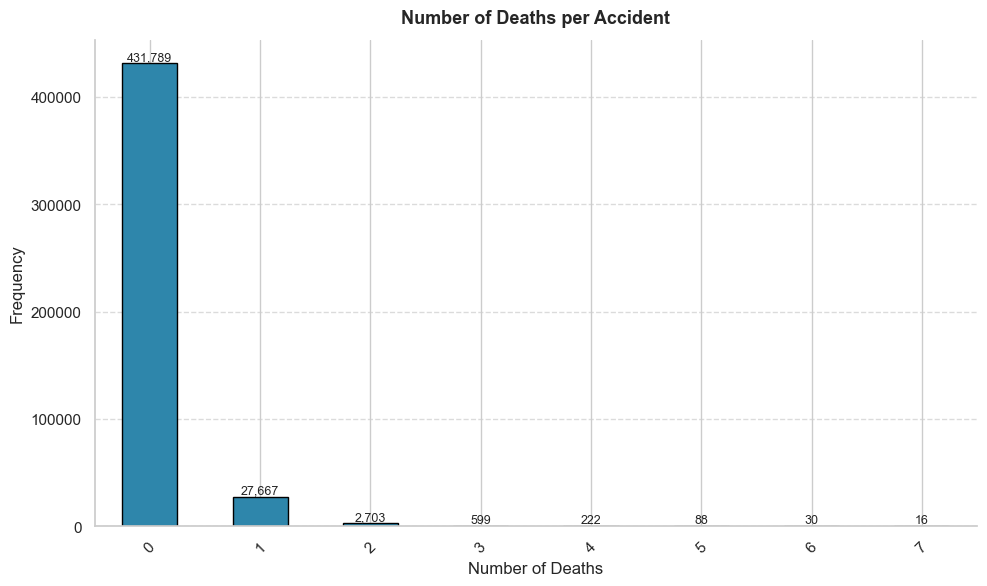

In [271]:
# Plot
plt.figure(figsize=(10, 6))
deaths_top = df['Deaths'].value_counts().sort_index().head(8)
bars = deaths_top.plot(kind='bar', color=PALETTE['primary'], edgecolor='black')

# Labels and title
plt.xlabel('Number of Deaths')
plt.ylabel('Frequency')
plt.title('Number of Deaths per Accident')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of bars
for i, (bar, v) in enumerate(zip(bars.patches, deaths_top.values)):
    plt.text(bar.get_x() + bar.get_width()/2, v + 0.5, f'{v:,}',
             ha='center', va='bottom', fontsize=9)

# Show the plot
plt.tight_layout()
plt.show()

The bar chart is heavy skewed. This means that most accidents do not result in fatalities.

### 8.2 · `Ignored` distribution (Enhanced)

`Ignored` records people whose condition was not reported. Roughly 12% of accidents have at least one ignored person.

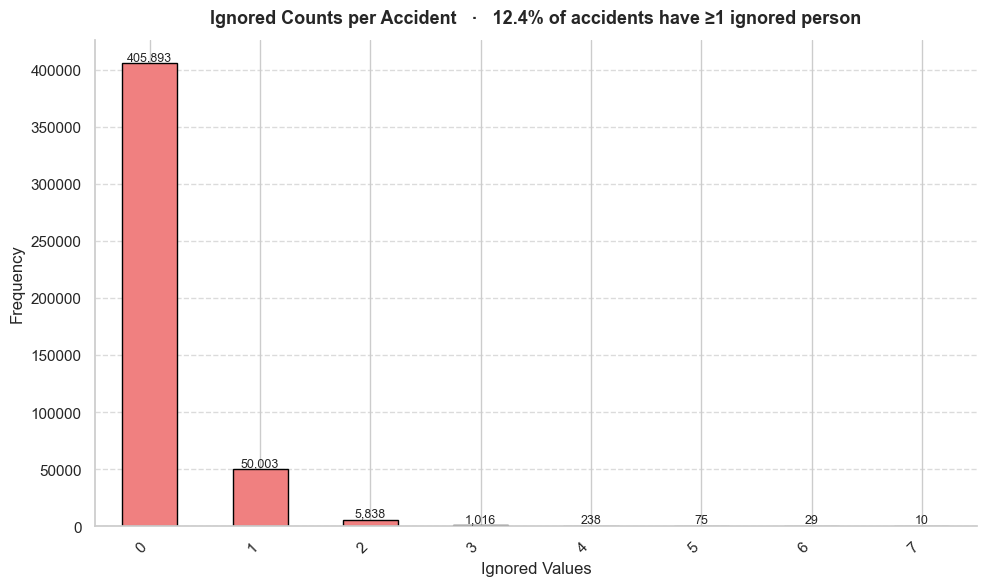

'12.4% of accidents have at least 1 ignored person'

In [272]:

# Calculate statistics
share = (df['Ignored'] > 0).mean()

# Plot
plt.figure(figsize=(10, 6))
ignored_top = df['Ignored'].value_counts().sort_index().head(8)
ignored_top.plot(kind='bar', color='lightcoral', edgecolor='black')

# Labels and title
plt.xlabel('Ignored Values')
plt.ylabel('Frequency')
plt.title(f'Ignored Counts per Accident   ·   {share:.1%} of accidents have ≥1 ignored person')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of bars
bars = plt.gca()
for i, (bar, v) in enumerate(zip(bars.patches, ignored_top.values)):
    plt.text(bar.get_x() + bar.get_width()/2, v + 0.5, f'{v:,}',
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Display the proportion
display(f"{share:.1%} of accidents have at least 1 ignored person")

### 8.3 · Logical checks

Two consistency checks:

* `Total_Injured` should equal `Slightly_Injured + Severely_Injured`.
* `People` should be ≥ `Vehicles_Involved`.

In [273]:
mismatch_total   = (df['Total_Injured'] != df['Slightly_Injured'] + df['Severely_Injured']).sum()
mismatch_people  = (df['People'] < df['Vehicles_Involved']).sum()

print(f"Total_Injured ≠ Slight + Severe : {mismatch_total}")
print(f"People < Vehicles_Involved      : {mismatch_people}")

if mismatch_total == 0 and mismatch_people == 0:
    print("\n Both checks pass => count columns are internally consistent.")

Total_Injured ≠ Slight + Severe : 0
People < Vehicles_Involved      : 0

 Both checks pass => count columns are internally consistent.


### 8.4 · Accident cause — raw distribution

The dataset uses 80+ free-text labels with a heavy long tail. Per supervisor feedback: **what is cause #1?**

In [274]:
cause_counts = df['Accident_Cause'].value_counts()
cause_share  = df['Accident_Cause'].value_counts(normalize=True)

print(f"Unique cause labels       : {df['Accident_Cause'].nunique()}")
print(f"#1 cause                  : {cause_counts.index[0]!r}")
print(f"   covers                 : {cause_share.iloc[0]:.1%} of all accidents")
print(f"Top 10 causes together    : {cause_share.head(10).sum():.1%}")

Unique cause labels       : 85
#1 cause                  : "Driver's lack of attention to conveyance"
   covers                 : 23.3% of all accidents
Top 10 causes together    : 69.5%


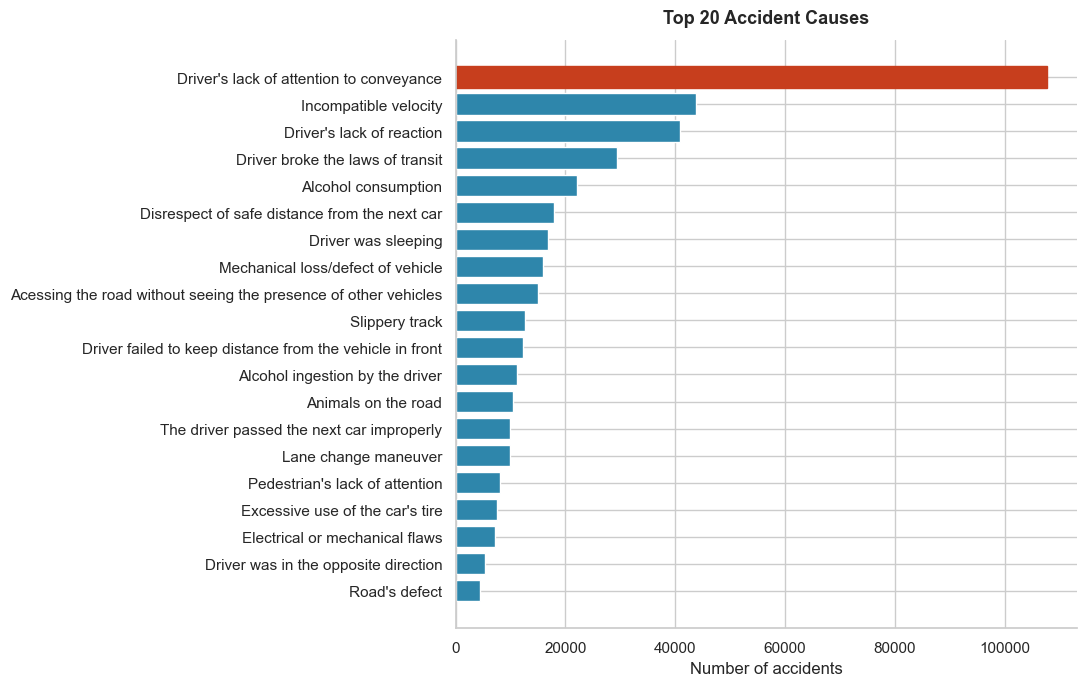

In [275]:
top20 = cause_counts.head(20)

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(top20.index, top20.values,
               color=PALETTE['primary'], edgecolor='white')
bars[0].set_color(PALETTE['danger'])     # highlight #1
ax.invert_yaxis()
ax.set(title='Top 20 Accident Causes', xlabel='Number of accidents', ylabel='')
plt.tight_layout(); plt.show()

**Findings:** *Driver's lack of attention to conveyance* dominates. Top 10 causes cover the large majority of the dataset, therefore the next step will be to try grouping them.

### 8.5 · Combining similar causes

There are more than 80 raw tags, which isn't adequate for this model. I'm trying to group them into broader categories by comparing substrings (to capture renamed tags or nearly duplicate tags as well).

In [276]:
print(df['Accident_Cause'].value_counts().to_string())

Accident_Cause
Driver's lack of attention to conveyance                           107788
Incompatible velocity                                               43722
Driver's lack of reaction                                           40883
Driver broke the laws of transit                                    29318
Alcohol consumption                                                 22140
Disrespect of safe distance from the next car                       17929
Driver was sleeping                                                 16820
Mechanical loss/defect of vehicle                                   15850
Acessing the road without seeing the presence of other vehicles     14973
Slippery track                                                      12648
Driver failed to keep distance from the vehicle in front            12262
Alcohol ingestion by the driver                                     11229
Animals on the road                                                 10533
The driver passed the n

In [277]:
def categorise_cause(c: str) -> str:
    """Map a raw accident-cause string to a broader category."""
    if not isinstance(c, str):
        return 'Unknown'
    s = c.lower()
    # alcohol & drugs first — they often appear inside other phrases
    if 'alcohol' in s or 'drug' in s:                          return 'Alcohol / Drugs'
    if 'pedestrian' in s:                                       return 'Pedestrian-related'
    if any(k in s for k in ['sleeping', 'cardiac', 'mental',
                             'cellphone']):                     return 'Driver state (fatigue / medical / distraction)'
    if any(k in s for k in ['velocity', 'distance', 'brake']):  return 'Speed & following distance'
    if any(k in s for k in ['mechanical', 'tire', 'electrical',
                             'suspension', 'headlight',
                             'sinalization/ilumination',
                             'load', 'cargo', 'modification']): return 'Vehicle defect'
    if any(k in s for k in ['slippery','pavement','pothole','holes',
                             'sand','wreckage','oil','water','drainage',
                             'drenage','curvy','downhill','unlevel',
                             'breakdown lane','obstacle','maintenance',
                             'speed reducer','static object',
                             "road's defect","flaws/problems in the road"]):
        return 'Road condition / infrastructure'
    if any(k in s for k in ['sinalization','ilumination of the road',
                             'visibility','fog','smoke','sign post',
                             'traffic light']):                  return 'Visibility & signage'
    if 'rain' in s or 'natural phenomena' in s:                  return 'Weather'
    if 'animal' in s:                                            return 'Animals'
    if any(k in s for k in ['lack of attention','lack of reaction',
                             'broke the laws','opposite direction',
                             'lane change','passed the next car',
                             'acessing the road','intersection',
                             'conversion','red traffic light','illegally',
                             'breakdown lane','irregular access',
                             'prohibited place','drifting',
                             'temporary return','on sidewalk']):
        return 'Driver behaviour'
    return 'Other'

df['Cause_Group'] = df['Accident_Cause'].apply(categorise_cause)
df['Cause_Group'].value_counts(normalize=True).mul(100).round(1)

Cause_Group
Driver behaviour                                 49.200
Speed & following distance                       16.400
Alcohol / Drugs                                   7.800
Vehicle defect                                    7.500
Road condition / infrastructure                   6.200
Driver state (fatigue / medical / distraction)    4.700
Pedestrian-related                                3.100
Animals                                           2.300
Visibility & signage                              1.200
Weather                                           1.000
Other                                             0.800
Name: proportion, dtype: float64

**Finding.** *Driver behaviour* (inattention, illegal manoeuvres, ignored signs) is dominant, followed by *Speed & following distance* and *Alcohol / Drugs*. Environmental factors (weather, animals, visibility) are responsible for a much smaller accidents.

### 8.6 · Contextual categorical columns


In [278]:
for col in ['Day_Phase', 'Weather_Condition', 'Road_Type', 'Road_Delineation', 'Km_Direction']:
    print(f"── {col} ──")
    print(df[col].value_counts().to_string())
    print()

── Day_Phase ──
Day_Phase
Day        253125
Night      161658
Sunset      25549
Sunrise     22801

── Weather_Condition ──
Weather_Condition
Clear sky    269949
Cloudy        78676
Rainy         54134
Sunny         32766
Drizzle       15986
Ignored        6673
Fog            3956
Windy           967
Hail             18
Snowy             8

── Road_Type ──
Road_Type
Simple      234099
Double      191619
Multiple     37415

── Road_Delineation ──
Road_Delineation
Straight             278785
Curve                 73506
Not Reported          58640
Intersection          19718
Temporary Detour      12257
Roundabout             8972
Authorized U-turn      5176
Overpass               3159
Bridge                 2395
Tunnel                  525

── Km_Direction ──
Km_Direction
Increasing      246682
Decreasing      215470
Not informed       981



### 8.7 · Time distribution

Derive time features once, then chart them. `Is_Weekend` is also derived here.

In [279]:
df['Hour']       = df['Datetime'].dt.hour
df['Month']      = df['Datetime'].dt.month
df['Weekday']    = df['Datetime'].dt.day_name()
df['Is_Weekend'] = df['Datetime'].dt.dayofweek >= 5   # Sat=5, Sun=6

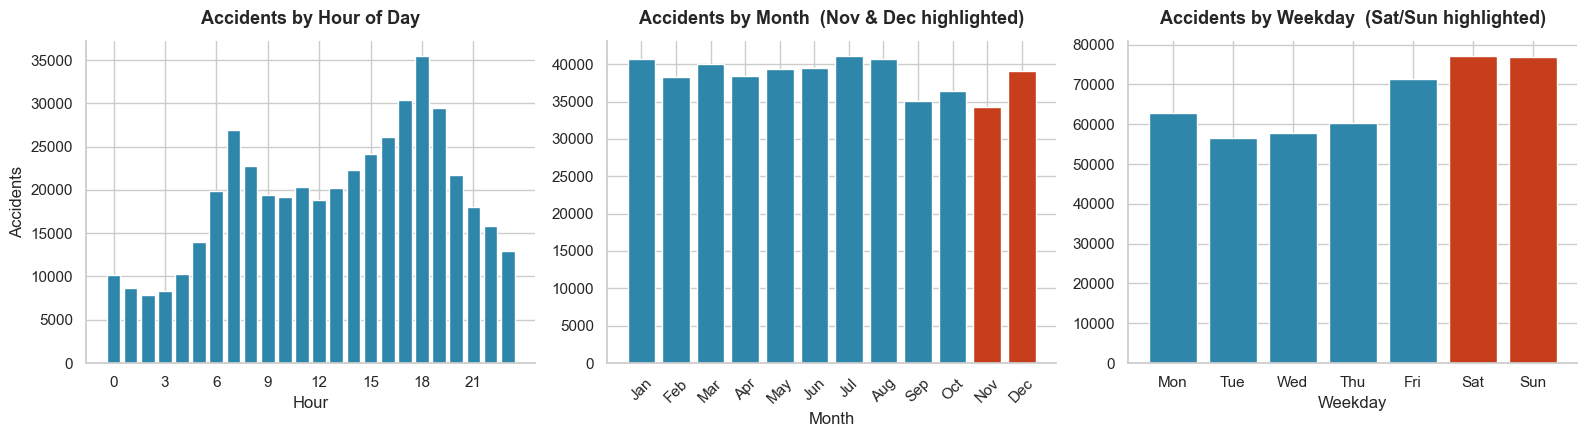

November: 34,321  ·  December: 39,122   (+14.0% Nov=>Dec)


In [280]:
hourly  = df['Hour'].value_counts().sort_index()
monthly = df['Month'].value_counts().sort_index()
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekly  = df['Weekday'].value_counts().reindex(weekday_order)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Hour
axes[0].bar(hourly.index, hourly.values, color=PALETTE['primary'], edgecolor='white')
axes[0].set(title='Accidents by Hour of Day', xlabel='Hour', ylabel='Accidents')
axes[0].set_xticks(range(0, 24, 3))

# Month — highlight Nov & Dec
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
month_colors = [PALETTE['primary']] * 10 + [PALETTE['danger']] * 2
axes[1].bar(month_names, monthly.values, color=month_colors, edgecolor='white')
axes[1].set(title='Accidents by Month  (Nov & Dec highlighted)', xlabel='Month', ylabel='')
axes[1].tick_params(axis='x', rotation=45)

# Weekday — highlight Sat/Sun
weekday_colors = [PALETTE['primary']] * 5 + [PALETTE['danger']] * 2
axes[2].bar([d[:3] for d in weekday_order], weekly.values,
            color=weekday_colors, edgecolor='white')
axes[2].set(title='Accidents by Weekday  (Sat/Sun highlighted)', xlabel='Weekday', ylabel='')

plt.tight_layout(); plt.show()

# Nov→Dec change
nov_dec_change = (monthly[12] - monthly[11]) / monthly[11] * 100
print(f"November: {monthly[11]:,}  ·  December: {monthly[12]:,}   ({nov_dec_change:+.1f}% Nov=>Dec)")

**Findings:**

* **Hour of day** - The number of cases rises from morning until 6:00–8:00 a.m., then drops slightly, only to climb back up to a peak in the late afternoon, likely during the evening rush hour between 5:00 and 7:00 p.m.,and drop again overnight.
* **November => December** — December shows a clear jump. Worth keeping `Month` as a model feature.
* **Weekday** — Saturday and Sunday are the two single highest-volume days of the week.

**Check** — does the original `Day` column agree with what we derive from `Datetime`?

In [281]:
df['Derived_Day'] = df['Datetime'].dt.day_name().str.lower()
mismatches = (df['Derived_Day'] != df['Day']).sum()
print(f"Mismatches between original Day and derived weekday: {mismatches}")

Mismatches between original Day and derived weekday: 0


In [282]:
df.groupby('Day_Phase')['Hour'].describe()

,count,mean,std,min,25%,50%,75%,max
Day_Phase,,,,,,,,
Day,"253,125.000",11.744,3.591,0.000,9.000,12.000,15.000,23.000
Night,"161,658.000",15.155,8.188,0.000,4.000,19.000,21.000,23.000
Sunrise,"22,801.000",5.538,1.791,0.000,5.000,5.000,6.000,23.000
Sunset,"25,549.000",17.482,1.310,0.000,17.000,17.000,18.000,23.000


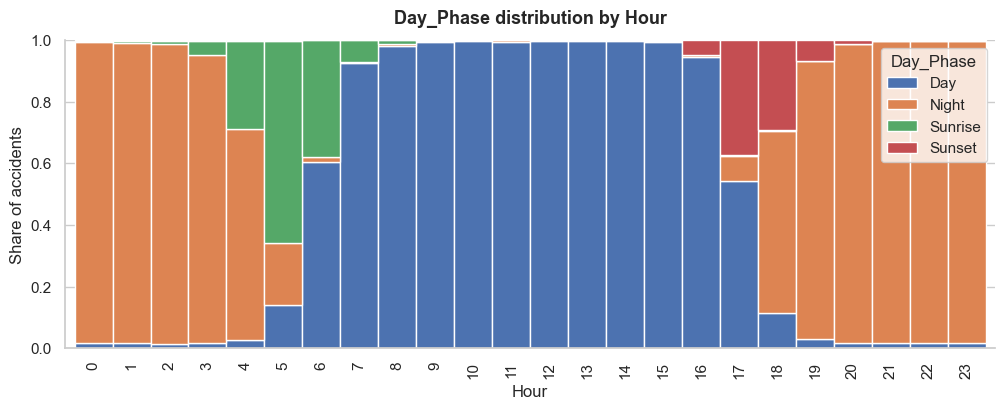

In [283]:
pd.crosstab(df['Hour'], df['Day_Phase'], normalize='index').plot(
    kind='bar', stacked=True, figsize=(12, 4), width=1.0,
    edgecolor='white', title='Day_Phase distribution by Hour'
)
plt.ylabel('Share of accidents')
plt.show()

Both attributes appear to be important. The Day_Phase column can be interpreted as lighting conditions, which likely depend on the season and geographic location. It reflects visibility rather than time, and is therefore important and should not be ignored. 

          accidents  avg_deaths  fatal_share
Datetime                                    
2017          89564       0.070        0.058
2018          69332       0.076        0.065
2019          67554       0.079        0.068
2020          63575       0.083        0.071
2021          64538       0.084        0.072
2022          64539       0.084        0.072
2023          44031       0.084        0.073


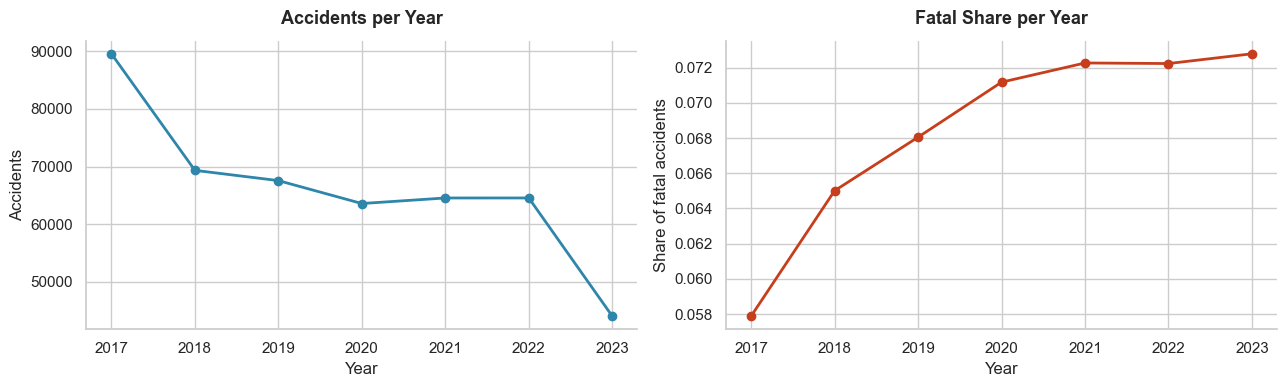

In [284]:
yearly = df.groupby(df['Datetime'].dt.year).agg(
    accidents   = ('Datetime', 'size'),
    avg_deaths  = ('Deaths', 'mean'),
    fatal_share = ('Deaths', lambda x: (x > 0).mean()),
)
print(yearly.round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(yearly.index, yearly['accidents'], marker='o',
             color=PALETTE['primary'], linewidth=2)
axes[0].set(title='Accidents per Year', xlabel='Year', ylabel='Accidents')

axes[1].plot(yearly.index, yearly['fatal_share'], marker='o',
             color=PALETTE['danger'], linewidth=2)
axes[1].set(title='Fatal Share per Year', xlabel='Year', ylabel='Share of fatal accidents')

plt.tight_layout(); plt.show()

Both graphs show a sharp decline and subsequent increase. It is clear that something happened between 2017 and 2018. At this point, I believe that there was a change in the accident reporting methodology within Brazil’s PRF system during the year. However, this is still concerning, especially when we see that the annual fatality graph has increased over time. It is worth noting whether I should leave 2023 in there, as the data from that year is incomplete.

### 8.8 · Working days vs Saturday / Sunday

Per supervisor feedback, compare working days (Mon–Fri) against the weekend (Sat–Sun)

In [285]:
per_day = df.groupby(df['Datetime'].dt.normalize()).size()

avg_weekday = per_day[per_day.index.dayofweek < 5].mean()
avg_weekend = per_day[per_day.index.dayofweek >= 5].mean()

# Severity by group
severity = df.groupby('Is_Weekend').agg(
    accidents                 = ('Deaths', 'size'),
    deaths_per_accident       = ('Deaths', 'mean'),
    severely_injured_per_acc  = ('Severely_Injured', 'mean'),
    fatal_share               = ('Deaths', lambda x: (x > 0).mean()),
)
severity.index = ['Working day (Mon–Fri)', 'Weekend (Sat–Sun)']
severity

,accidents,deaths_per_accident,severely_injured_per_acc,fatal_share
Working day (Mon–Fri),309043,0.072,0.244,0.062
Weekend (Sat–Sun),154090,0.094,0.292,0.080


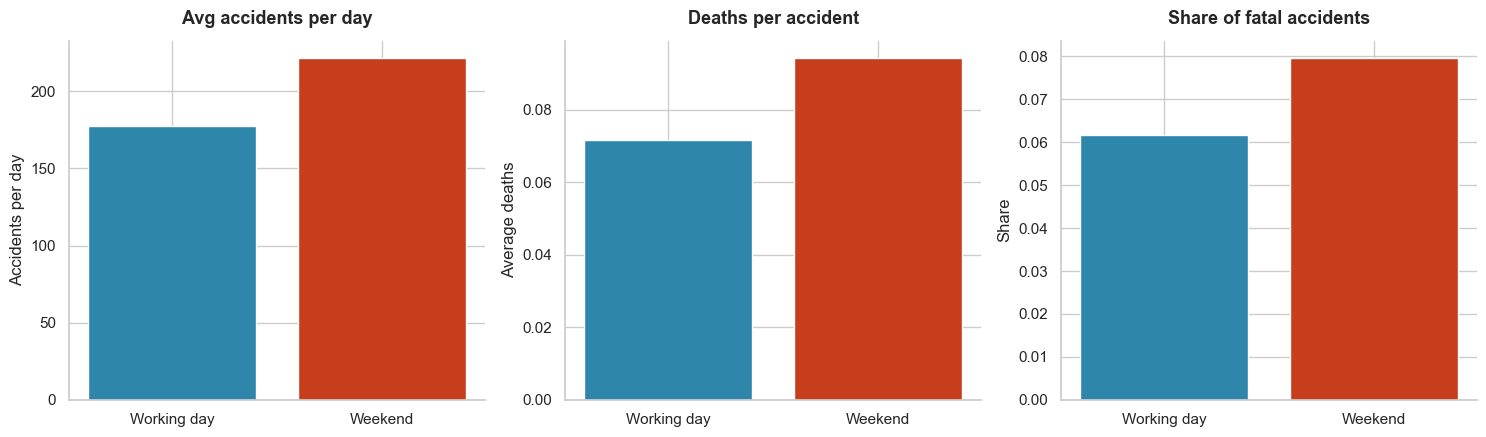

In [286]:
labels  = ['Working day', 'Weekend']
colors  = [PALETTE['primary'], PALETTE['danger']]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].bar(labels, [avg_weekday, avg_weekend], color=colors, edgecolor='white')
axes[0].set(title='Avg accidents per day', ylabel='Accidents per day')

axes[1].bar(labels, severity['deaths_per_accident'].values, color=colors, edgecolor='white')
axes[1].set(title='Deaths per accident', ylabel='Average deaths')

axes[2].bar(labels, severity['fatal_share'].values, color=colors, edgecolor='white')
axes[2].set(title='Share of fatal accidents', ylabel='Share')

plt.tight_layout(); plt.show()

**Finding.** Weekends are both *more frequent* **and** *more severe*. The combination justifies keeping `Is_Weekend` as a feature.

In [287]:
# Per-weekday volumes and severity 
per_weekday = df.groupby('Weekday').agg(
    total_accidents    = ('Deaths', 'size'),
    total_deaths       = ('Deaths', 'sum'),
    avg_deaths         = ('Deaths', 'mean'),
    fatal_share        = ('Deaths', lambda x: (x > 0).mean()),
).reindex(weekday_order)

print(per_weekday.round(4).to_string())

# How many actual Saturdays/Sundays vs weekdays in the dataset?
day_counts = df.groupby(df['Datetime'].dt.normalize().rename('day')).first().reset_index()
day_counts['dow'] = day_counts['day'].dt.day_name()
calendar_days = day_counts['dow'].value_counts().reindex(weekday_order)
print('\nCalendar days observed per weekday:')
print(calendar_days.to_string())

           total_accidents  total_deaths  avg_deaths  fatal_share
Weekday                                                          
Monday               62813          4658       0.074        0.064
Tuesday              56599          3892       0.069        0.059
Wednesday            57873          3974       0.069        0.059
Thursday             60326          4325       0.072        0.062
Friday               71432          5320       0.074        0.064
Saturday             77132          6836       0.089        0.075
Sunday               76958          7693       0.100        0.084

Calendar days observed per weekday:
dow
Monday       348
Tuesday      348
Wednesday    348
Thursday     348
Friday       347
Saturday     347
Sunday       348


The results show that, in terms of the volume of data in the dataset, Saturdays and Sundays are no different from other days. Another point I must mention is that Sundays are much more dangerous than Saturdays. From this, I conclude that I must analyze this information and take the necessary measures to address this issue.

8.8.1

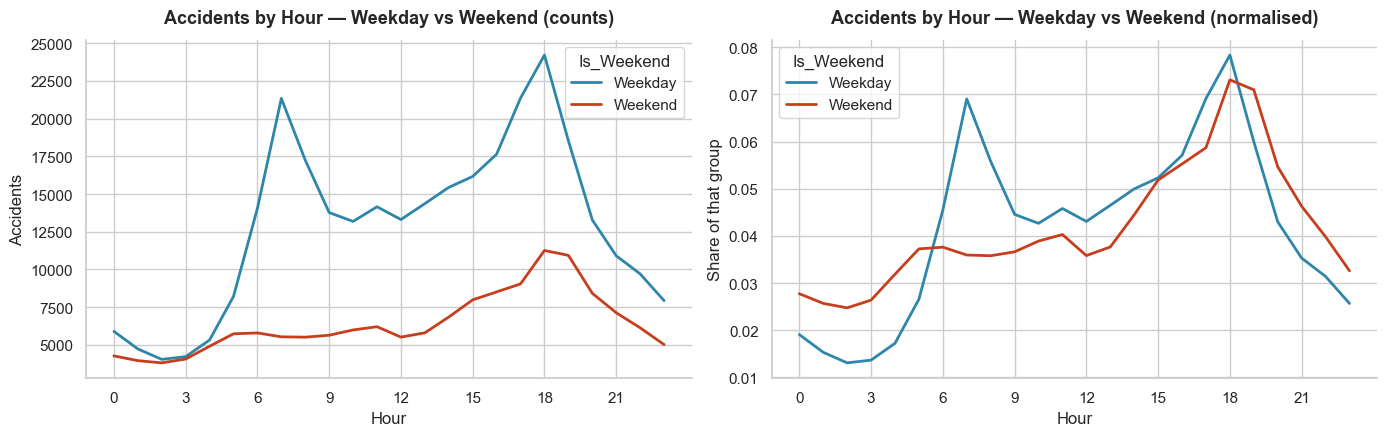

In [288]:
# Hour of day pattern, split by weekend vs weekday
hourly_split = (df.groupby(['Is_Weekend', 'Hour'])
                  .size()
                  .unstack(level=0)
                  .rename(columns={False: 'Weekday', True: 'Weekend'}))

# Normalise so the shapes are comparable (weekdays have around 5 times more days)
hourly_split_norm = hourly_split.div(hourly_split.sum(axis=0), axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Raw counts
hourly_split.plot(ax=axes[0], color=[PALETTE['primary'], PALETTE['danger']], linewidth=2)
axes[0].set(title='Accidents by Hour — Weekday vs Weekend (counts)',
            xlabel='Hour', ylabel='Accidents')
axes[0].set_xticks(range(0, 24, 3))

# Normalised, whihc should show the "shape" difference
hourly_split_norm.plot(ax=axes[1], color=[PALETTE['primary'], PALETTE['danger']], linewidth=2)
axes[1].set(title='Accidents by Hour — Weekday vs Weekend (normalised)',
            xlabel='Hour', ylabel='Share of that group')
axes[1].set_xticks(range(0, 24, 3))

plt.tight_layout(); plt.show()

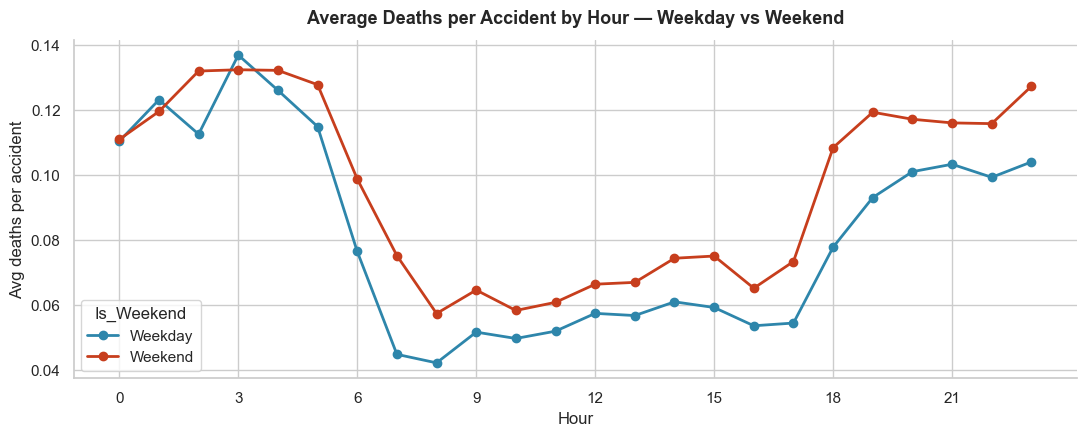

In [289]:
# Severity by hour, split by weekend
hourly_severity = (df.groupby(['Is_Weekend', 'Hour'])['Deaths']
                     .mean()
                     .unstack(level=0)
                     .rename(columns={False: 'Weekday', True: 'Weekend'}))

fig, ax = plt.subplots(figsize=(11, 4.5))
hourly_severity.plot(ax=ax, color=[PALETTE['primary'], PALETTE['danger']], linewidth=2, marker='o')
ax.set(title='Average Deaths per Accident by Hour — Weekday vs Weekend',
       xlabel='Hour', ylabel='Avg deaths per accident')
ax.set_xticks(range(0, 24, 3))
plt.tight_layout(); plt.show()

These results show that the most serious accidents occur during the night, between 6:00 p.m. and 5:00 a.m. It appears that the number of fatalities is two to three times higher during these hours, regardless of the day of the week.

In [290]:
df['Day_Type'] = np.select(
    [df['Datetime'].dt.dayofweek < 5,
     df['Datetime'].dt.dayofweek == 5,
     df['Datetime'].dt.dayofweek == 6],
    ['Weekday', 'Saturday', 'Sunday'],
    default='Unknown'
)

In [291]:
severity = df.groupby('Day_Type').agg(
    accidents                 = ('Deaths', 'size'),
    deaths_per_accident       = ('Deaths', 'mean'),
    severely_injured_per_acc  = ('Severely_Injured', 'mean'),
    fatal_share               = ('Deaths', lambda x: (x > 0).mean()),
).reindex(['Weekday', 'Saturday', 'Sunday'])
severity

,accidents,deaths_per_accident,severely_injured_per_acc,fatal_share
Day_Type,,,,
Weekday,309043,0.072,0.244,0.062
Saturday,77132,0.089,0.285,0.075
Sunday,76958,0.100,0.299,0.084


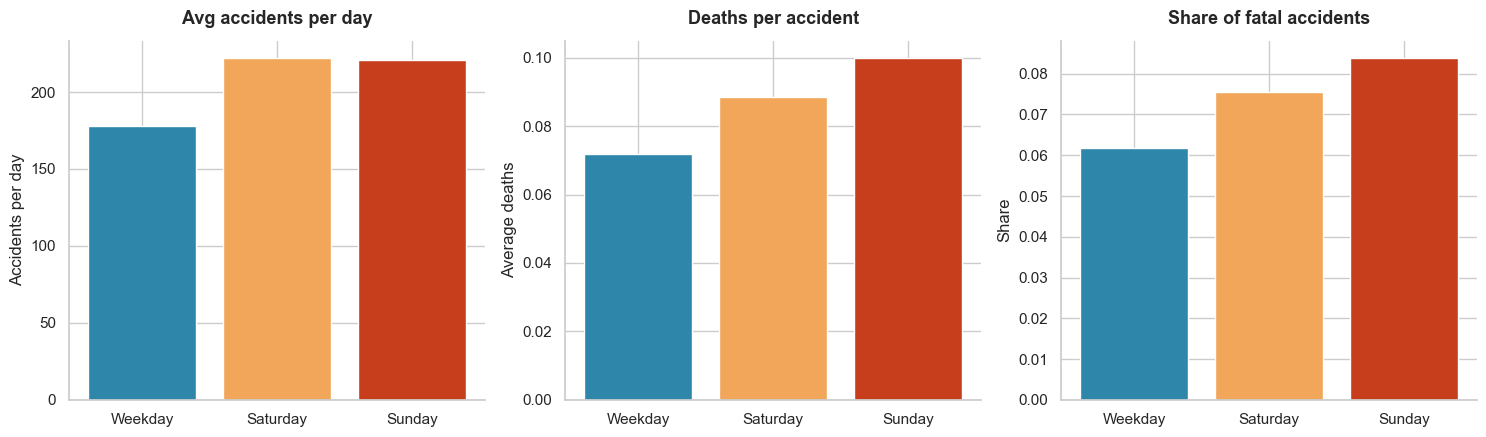

In [292]:
labels  = ['Weekday', 'Saturday', 'Sunday']
colors  = [PALETTE['primary'], PALETTE['warn'], PALETTE['danger']]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Avg accidents per calendar day of that type
per_day = df.groupby(df['Datetime'].dt.normalize()).size()
day_of_week = per_day.index.dayofweek
avg_per_daytype = [
    per_day[day_of_week < 5].mean(),
    per_day[day_of_week == 5].mean(),
    per_day[day_of_week == 6].mean(),
]
axes[0].bar(labels, avg_per_daytype, color=colors, edgecolor='white')
axes[0].set(title='Avg accidents per day', ylabel='Accidents per day')

axes[1].bar(labels, severity['deaths_per_accident'].values, color=colors, edgecolor='white')
axes[1].set(title='Deaths per accident', ylabel='Average deaths')

axes[2].bar(labels, severity['fatal_share'].values, color=colors, edgecolor='white')
axes[2].set(title='Share of fatal accidents', ylabel='Share')

plt.tight_layout(); plt.show()

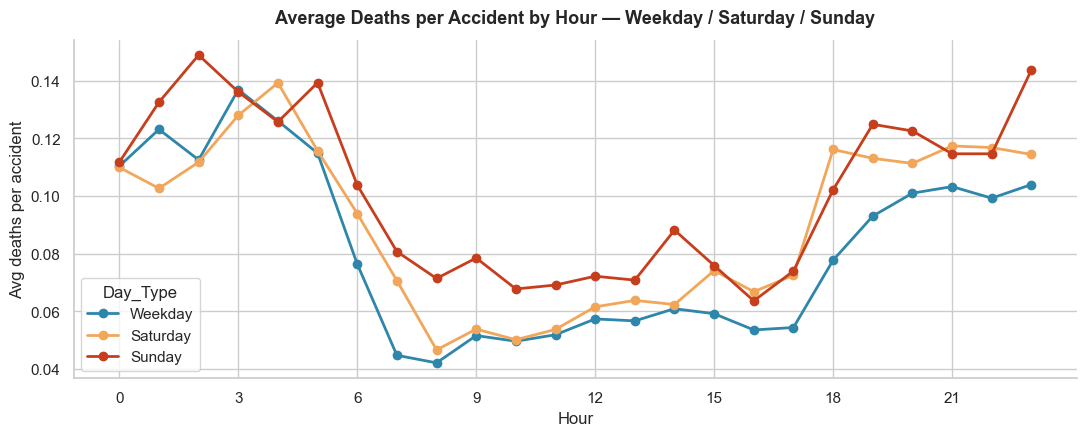

In [293]:
hourly_by_daytype = (df.groupby(['Day_Type', 'Hour'])['Deaths']
                       .mean()
                       .unstack(level=0)
                       [['Weekday', 'Saturday', 'Sunday']])

fig, ax = plt.subplots(figsize=(11, 4.5))
hourly_by_daytype.plot(ax=ax, linewidth=2, marker='o',
                       color=[PALETTE['primary'], PALETTE['warn'], PALETTE['danger']])
ax.set(title='Average Deaths per Accident by Hour — Weekday / Saturday / Sunday',
       xlabel='Hour', ylabel='Avg deaths per accident')
ax.set_xticks(range(0, 24, 3))
plt.tight_layout(); plt.show()

### 8.9 · Victims condition  (target variable)

                       count  share
Victims_Condition                  
With injured victims  332206  0.717
Without victims        99583  0.215
With dead victims      31344  0.068

Deaths per accident by class:
Victims_Condition
With injured victims   0.000
Without victims        0.000
With dead victims      1.171


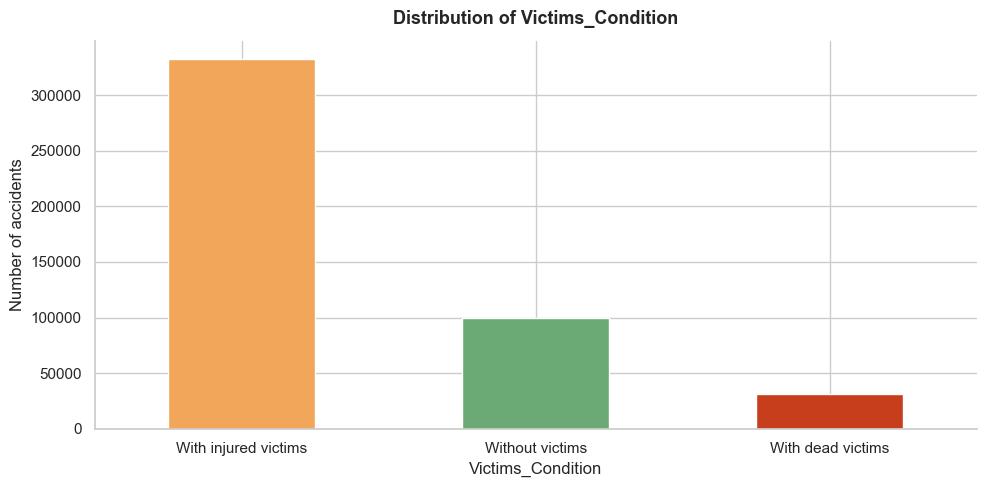

In [294]:
victim_counts = df['Victims_Condition'].value_counts()
victim_share  = df['Victims_Condition'].value_counts(normalize=True)

summary = pd.DataFrame({'count': victim_counts, 'share': victim_share})
print(summary.to_string())

print('\nDeaths per accident by class:')
print(df.groupby('Victims_Condition')['Deaths'].mean().sort_values().to_string())

victim_counts.plot(kind='bar', color=[PALETTE['warn'], PALETTE['ok'], PALETTE['danger']])
plt.title('Distribution of Victims_Condition')
plt.ylabel('Number of accidents')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Heavy class imbalance — *with injured victims* are the most common, while fatal accidents make up the smallest group => An imbalance that will need to be addressed later.

---
## 9 · Bivariate / multivariate analysis

### 9.1 · Weather and day-phase context

In [295]:
print('Total deaths by weather:')
print(df.groupby('Weather_Condition')['Deaths'].sum().sort_values(ascending=False).to_string())
print('\nMean deaths/ignored by day phase:')
print(df.groupby('Day_Phase')[['Deaths', 'Ignored']].mean().round(4).to_string())

Total deaths by weather:
Weather_Condition
Clear sky    22405
Cloudy        6055
Rainy         3865
Sunny         1933
Drizzle       1105
Ignored        710
Fog            541
Windy           83
Hail             1
Snowy            0

Mean deaths/ignored by day phase:
           Deaths  Ignored
Day_Phase                 
Day         0.057    0.118
Night       0.110    0.180
Sunrise     0.116    0.160
Sunset      0.073    0.156


This was meant to show the deaths by Weather_Condition and Day_Phase. As we can see Nights and Sunrise are the deadliest. Weather, on the other hand, most likely did not contribute much. This can mean the Day_Phase is worth keeping and Weather_Condition will likely contribute less for feature importance. 

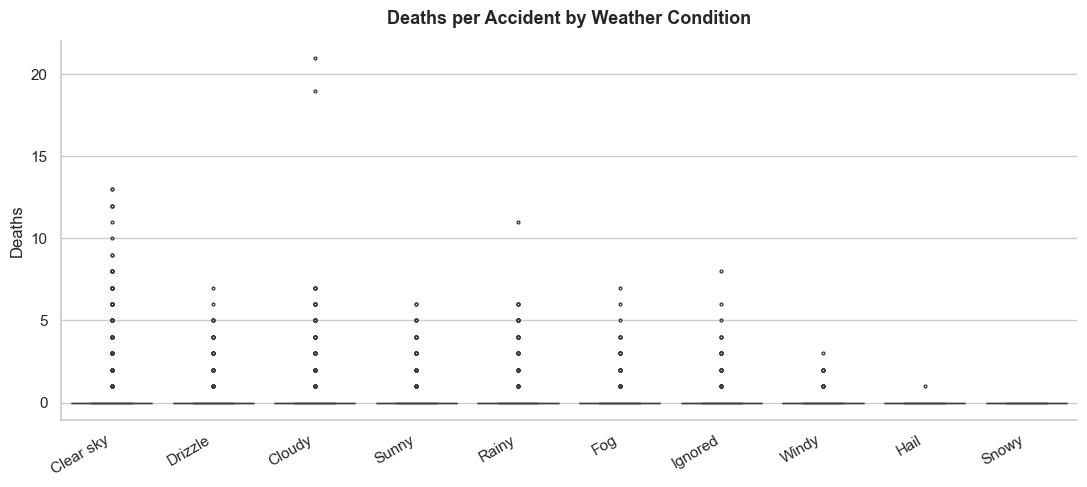

In [296]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=df, x='Weather_Condition', y='Deaths',
            color=PALETTE['primary'], ax=ax, fliersize=2)
ax.set(title='Deaths per Accident by Weather Condition', xlabel='', ylabel='Deaths')
ax.tick_params(axis='x', rotation=30)
for label in ax.get_xticklabels():
    label.set_horizontalalignment('right')
plt.tight_layout(); plt.show()

### 9.2 · Correlation — vehicles, injuries, deaths

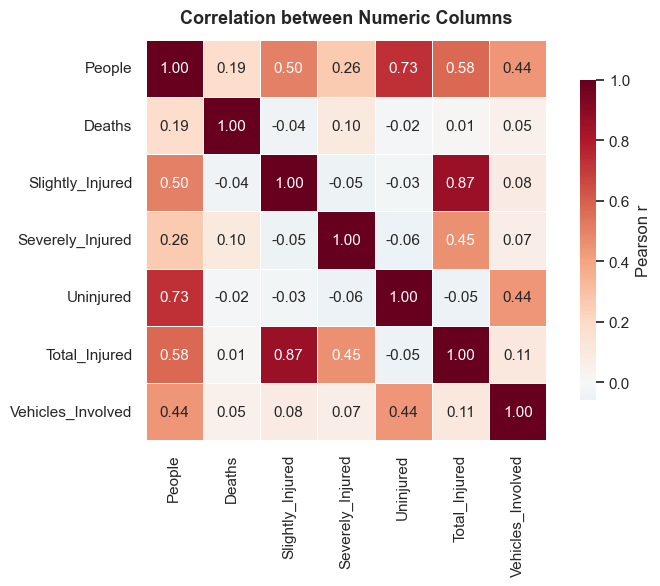

In [297]:
corr_cols = ['People','Deaths','Slightly_Injured','Severely_Injured',
             'Uninjured','Total_Injured','Vehicles_Involved']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8, 'label': 'Pearson r'})
ax.set_title('Correlation between Numeric Columns')
plt.tight_layout(); plt.show()

This is mostly sanity check, not a finding. This shows correlation between outcome columns. No meaningful analytical insights. These types of columns are not important for machine learning models. Most likely to be dropped before modelling. 

In [298]:
vehicles_severity = df.groupby('Vehicles_Involved').agg(
    accidents   = ('Deaths', 'size'),
    avg_deaths  = ('Deaths', 'mean'),
).head(10)
print(vehicles_severity.round(4).to_string())

                   accidents  avg_deaths
Vehicles_Involved                       
1                     212586       0.064
2                     215336       0.088
3                      26638       0.117
4                       5844       0.101
5                       1701       0.119
6                        603       0.154
7                        219       0.205
8                         84       0.262
9                         45       0.267
10                        25       0.240


### 9.3 · Road type × road delineation

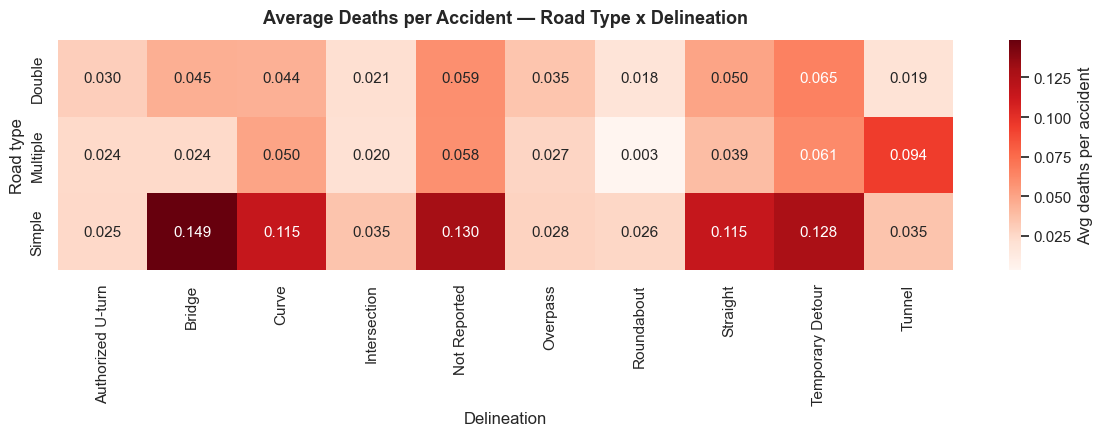

In [299]:
road_pivot = (df.groupby(['Road_Type', 'Road_Delineation'])['Deaths']
                .mean().unstack())

fig, ax = plt.subplots(figsize=(12, 4.5))
sns.heatmap(road_pivot, annot=True, fmt='.3f', cmap='Reds',
            cbar_kws={'label': 'Avg deaths per accident'}, ax=ax)
ax.set(title='Average Deaths per Accident — Road Type x Delineation',
       xlabel='Delineation', ylabel='Road type')
plt.tight_layout(); plt.show()

Simple roads are deadlier than Multiple or Double, with Simple × Bridge (0.149) and Simple × Temporary Detour (0.128) the deadliest combinations.

### 9.4 · Severity by State and Regional district

Three views, per supervisor feedback:

1. Average deaths per accident by State.
2. Severity-class mix (no-victims / injured / dead) by State.
3. Same severity mix by `Regional` district.

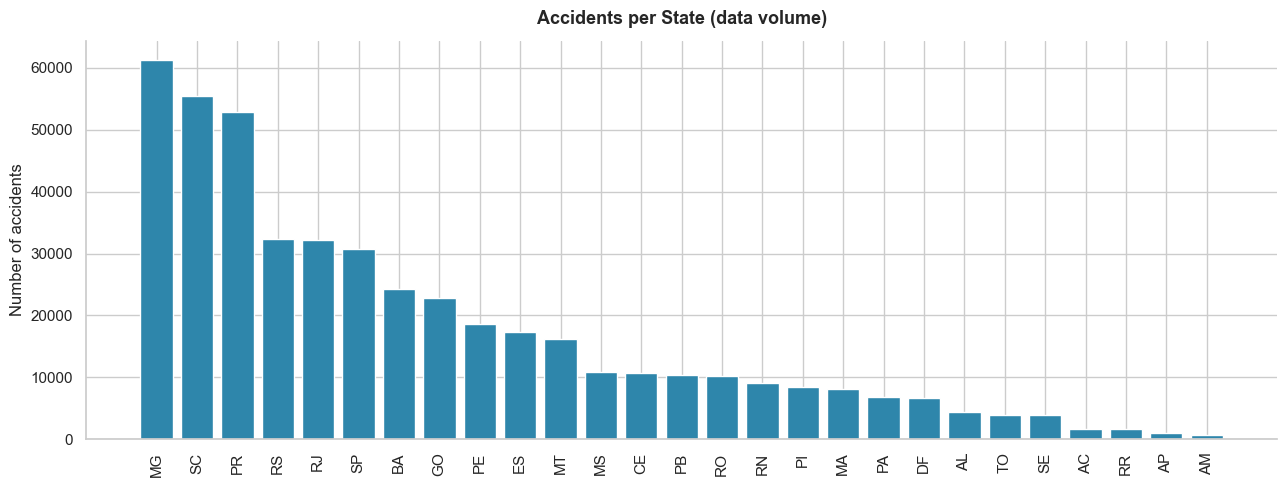

Largest state: MG (61,321 accidents)
Smallest state: AM (772 accidents)
Ratio: 79x


In [300]:
# How much data does each state contribute?
state_volume = df['State'].value_counts().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(state_volume.index, state_volume.values,
       color=PALETTE['primary'], edgecolor='white')
ax.set(title='Accidents per State (data volume)', ylabel='Number of accidents', xlabel='')
ax.tick_params(axis='x', rotation=90)
plt.tight_layout(); plt.show()

print(f"Largest state: {state_volume.index[0]} ({state_volume.iloc[0]:,} accidents)")
print(f"Smallest state: {state_volume.index[-1]} ({state_volume.iloc[-1]:,} accidents)")
print(f"Ratio: {state_volume.iloc[0] / state_volume.iloc[-1]:.0f}x")

Based on this result, the dataset is significantly imbalance, not only in terms of accident types but also in terms of the proportion of data from each state. I have to address this issue or accept it and proceed.

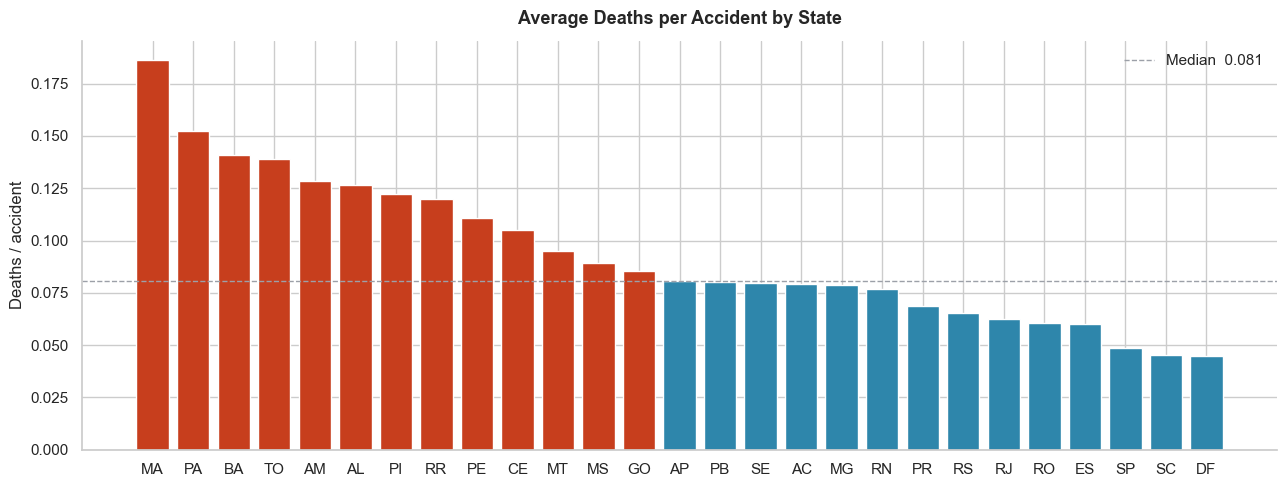

In [301]:
state_deaths = df.groupby('State')['Deaths'].mean().sort_values(ascending=False)
median = state_deaths.median()

fig, ax = plt.subplots(figsize=(13, 5))
colors = np.where(state_deaths > median, PALETTE['danger'], PALETTE['primary'])
ax.bar(state_deaths.index, state_deaths.values, color=colors, edgecolor='white')
ax.set(title='Average Deaths per Accident by State', ylabel='Deaths / accident', xlabel='')
ax.axhline(median, color=PALETTE['muted'], linestyle='--', linewidth=1,
           label=f'Median  {median:.3f}')
ax.legend(loc='upper right', frameon=False)
plt.tight_layout(); plt.show()

In [302]:
# Why is MA's average so high?
state_profile = df.groupby('State').agg(
    accidents          = ('Deaths', 'size'),
    avg_deaths         = ('Deaths', 'mean'),
    total_deaths       = ('Deaths', 'sum'),
    fatal_share        = ('Deaths', lambda x: (x > 0).mean()),
).sort_values('avg_deaths', ascending=False)

print(state_profile.round(4).to_string())

# Focus on MA
print('\nMA in context:')
print(state_profile.loc['MA'])
print(f"\nMA accidents as % of total: {state_profile.loc['MA','accidents'] / state_profile['accidents'].sum():.2%}")
print(f"National avg deaths/accident: {df['Deaths'].mean():.4f}")

       accidents  avg_deaths  total_deaths  fatal_share
State                                                  
MA          8049       0.186          1499        0.155
PA          6798       0.152          1035        0.132
BA         24337       0.141          3426        0.115
TO          3974       0.139           552        0.118
AM           772       0.128            99        0.113
AL          4427       0.127           561        0.110
PI          8522       0.122          1040        0.106
RR          1601       0.120           192        0.108
PE         18674       0.111          2070        0.100
CE         10726       0.105          1125        0.094
MT         16272       0.095          1547        0.077
MS         10862       0.089           968        0.073
GO         22746       0.086          1945        0.070
AP          1066       0.081            86        0.068
PB         10325       0.080           827        0.073
SE          3871       0.080           308      

Based on these findings, MA is indeed more deadly. There were “only” 8,049 accidents in this state, but that is sufficient to make the result reliable. It is clear that the proportion of fatal accidents is 15.5%, which is 3 to 4 times higher than in southern states such as SC, where this proportion is only 3.9%. As we can see, the northern states (PA, MA, TO) show higher fatality rates in this case, indicating a regional trend rather than isolated exceptions in individual states. 

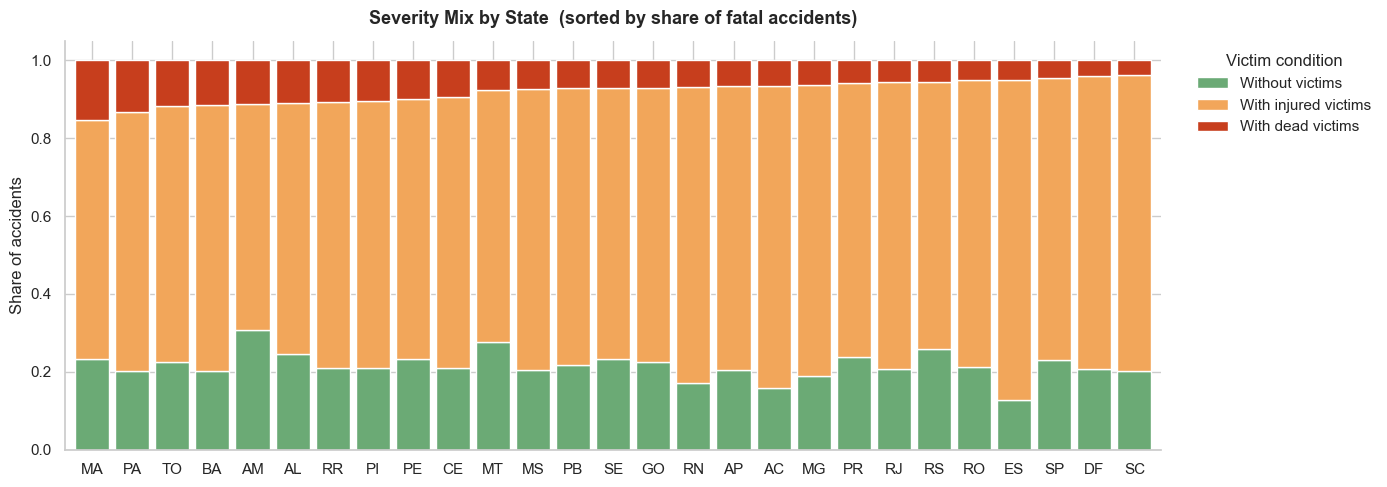

In [303]:
# Severity-class share by State, sorted by share-of-fatal
order_cols = ['Without victims', 'With injured victims', 'With dead victims']
state_severity = (df.groupby('State')['Victims_Condition']
                    .value_counts(normalize=True).unstack(fill_value=0)
                    [order_cols]
                    .sort_values('With dead victims', ascending=False))

fig, ax = plt.subplots(figsize=(14, 5))
state_severity.plot(kind='bar', stacked=True, ax=ax,
                    color=SEVERITY_COLORS, edgecolor='white', width=0.85)
ax.set(title='Severity Mix by State  (sorted by share of fatal accidents)',
       ylabel='Share of accidents', xlabel='')
ax.legend(title='Victim condition', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
ax.tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

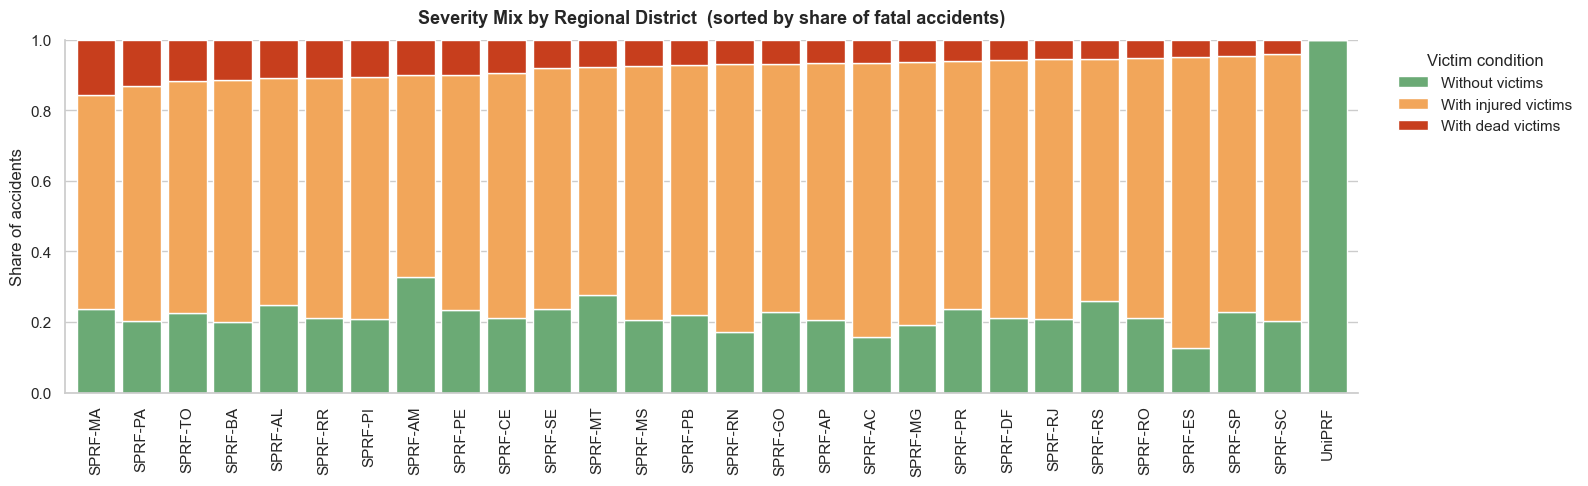

In [304]:
# Same view, by Regional
regional_severity = (df.groupby('Regional')['Victims_Condition']
                       .value_counts(normalize=True).unstack(fill_value=0)
                       [order_cols]
                       .sort_values('With dead victims', ascending=False))

fig, ax = plt.subplots(figsize=(16, 5))
regional_severity.plot(kind='bar', stacked=True, ax=ax,
                       color=SEVERITY_COLORS, edgecolor='white', width=0.85)
ax.set(title='Severity Mix by Regional District  (sorted by share of fatal accidents)',
       ylabel='Share of accidents', xlabel='')
ax.legend(title='Victim condition', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
ax.tick_params(axis='x', rotation=90)
plt.tight_layout(); plt.show()

In [305]:
print(df['Regional'].value_counts().to_string())

Regional
SPRF-MG    61177
SPRF-SC    55720
SPRF-PR    52576
SPRF-RS    32463
SPRF-RJ    32229
SPRF-SP    30694
SPRF-BA    23837
SPRF-PE    19124
SPRF-ES    17308
SPRF-MT    16196
SPRF-GO    15799
SPRF-DF    13583
SPRF-MS    10909
SPRF-CE    10757
SPRF-RO    10403
SPRF-PB    10294
SPRF-RN     9145
SPRF-PI     8711
SPRF-MA     7860
SPRF-PA     6797
SPRF-AL     4364
SPRF-SE     4128
SPRF-TO     3974
SPRF-AC     1744
SPRF-RR     1601
SPRF-AP     1067
SPRF-AM      672
UniPRF         1


In [306]:
(df[df['Deaths'] > 0]
   .groupby('State')['Deaths'].mean()
   .sort_values(ascending=False)
   .round(3))

State
MT   1.230
BA   1.229
MG   1.219
GO   1.217
MS   1.215
AC   1.212
MA   1.203
AP   1.194
ES   1.194
RO   1.194
RS   1.183
TO   1.179
PR   1.159
PI   1.156
PA   1.155
AL   1.152
SC   1.152
AM   1.138
RJ   1.126
PE   1.113
CE   1.111
RR   1.110
RN   1.105
SE   1.104
PB   1.101
SP   1.083
DF   1.080
Name: Deaths, dtype: float64

https://agenciadenoticias.ibge.gov.br/en/agencia-news/2184-news-agency/news/19438-divide-to-know-the-regional-divisions-of-brazil

link to a map to verify the brazil regions

In [307]:
# Map states to the five Brazilian macro-regions
brazil_regions = {
    'North':       ['AC','AM','AP','PA','RO','RR','TO'],
    'Northeast':   ['AL','BA','CE','MA','PB','PE','PI','RN','SE'],
    'Centre-West': ['DF','GO','MT','MS'],
    'Southeast':   ['ES','MG','RJ','SP'],
    'South':       ['PR','RS','SC'],
}
state_to_region = {}
for region, states in brazil_regions.items():
    for state in states:
        state_to_region[state] = region
df['Region_BR'] = df['State'].map(state_to_region)

region_profile = df.groupby('Region_BR').agg(
    accidents   = ('Datetime', 'size'),
    injured_share  = ('Victims_Condition', lambda x: (x == 'With injured victims').mean()),
    fatal_share = ('Victims_Condition', lambda x: (x == 'With dead victims').mean()),
).sort_values('fatal_share', ascending=False)

print(region_profile.round(4).to_string())

             accidents  injured_share  fatal_share
Region_BR                                         
Northeast        98076          0.684        0.102
North            26182          0.701        0.089
Centre-West      56516          0.696        0.070
Southeast       141603          0.748        0.057
South           140756          0.721        0.051


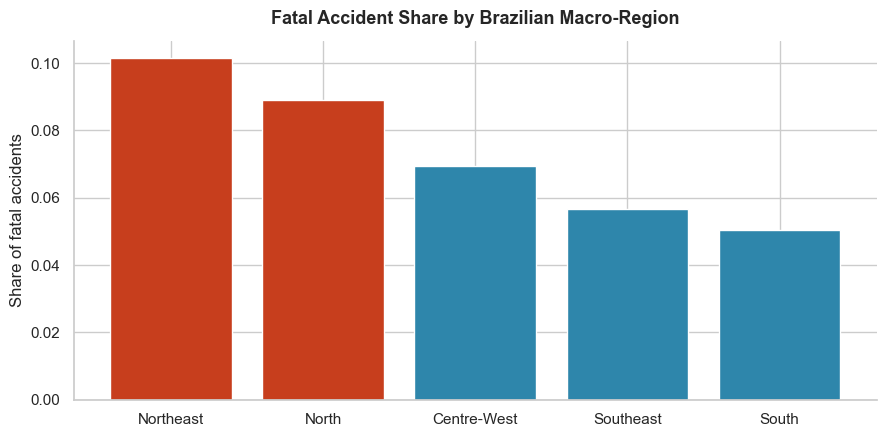

In [308]:
fig, ax = plt.subplots(figsize=(9, 4.5))
colors = [PALETTE['danger'] if v > 0.07 else PALETTE['primary']
          for v in region_profile['fatal_share']]
ax.bar(region_profile.index, region_profile['fatal_share'].values,
       color=colors, edgecolor='white')
ax.set(title='Fatal Accident Share by Brazilian Macro-Region',
       ylabel='Share of fatal accidents', xlabel='')
plt.tight_layout(); plt.show()

The most severe region in Brazil is Northeast.

In [309]:
reporting_check = df.groupby('Region_BR')['Victims_Condition'].value_counts(normalize=True).unstack()
print(reporting_check.round(3))

Victims_Condition  With dead victims  With injured victims  Without victims
Region_BR                                                                  
Centre-West                    0.070                 0.696            0.234
North                          0.089                 0.701            0.210
Northeast                      0.102                 0.684            0.214
South                          0.051                 0.721            0.229
Southeast                      0.057                 0.748            0.195


I had assumed that the proportion of fatal accidents was higher in the northern and northeastern regions because less accidents without casualties had been reported there, but as it turned out, that is not the case. Therefore I am assuming few things at the moment:

* Emergency response time and hospital access is less adequante in those areas.
* Possibility of older vehicles
* Road characteristics

In [310]:
# Cause mix by region — does the Northeast skew toward deadlier causes?
print("Cause_Group share by region")
print((pd.crosstab(df['Region_BR'], df['Cause_Group'], normalize='index')
       .round(3) * 100).to_string())

Cause_Group share by region
Cause_Group  Alcohol / Drugs  Animals  Driver behaviour  Driver state (fatigue / medical / distraction)  Other  Pedestrian-related  Road condition / infrastructure  Speed & following distance  Vehicle defect  Visibility & signage  Weather
Region_BR                                                                                                                                                                                                                                     
Centre-West            9.700    2.700            48.700                                           5.900  0.700               2.500                            7.000                      11.700           8.800                 1.100    1.200
North                  8.400    2.400            55.300                                           2.800  0.400               3.000                            8.300                       9.800           6.600                 2.100    0.700
Northeast       

No strong interaction visible

In [311]:
# Road type by region — does the Northeast have more single-lane roads?
print("Road_Type share by region")
print((pd.crosstab(df['Region_BR'], df['Road_Type'], normalize='index')
       .round(3) * 100).to_string())

Road_Type share by region
Road_Type    Double  Multiple  Simple
Region_BR                            
Centre-West  46.000     2.100  51.900
North        30.400     3.800  65.900
Northeast    33.800     6.700  59.500
South        40.800     9.000  50.100
Southeast    47.300    11.300  41.400


North has approximatelly 1.6 times higher to have simple road than Southeast. This is possible explanation why is the North and Northeast more deadlier.

In [312]:
# Time of day by region — does the Northeast skew toward night?
print("Time_Period share by region")
df['Hour'] = df['Datetime'].dt.hour

def time_bucket(h):
    if   5  <= h < 12: return 'Morning'
    elif 12 <= h < 17: return 'Afternoon'
    elif 17 <= h < 21: return 'Evening'
    else:              return 'Night'

df['Time_Period'] = df['Hour'].apply(time_bucket)
print((pd.crosstab(df['Region_BR'], df['Time_Period'], normalize='index')
       .round(3) * 100).to_string())

Time_Period share by region
Time_Period  Afternoon  Evening  Morning  Night
Region_BR                                      
Centre-West     24.900   25.400   30.400 19.300
North           24.700   26.100   31.900 17.300
Northeast       23.600   26.500   31.300 18.600
South           23.700   25.900   29.700 20.800
Southeast       24.500   23.600   31.300 20.600


No visible difference. Time of day is not a regional explanation.

In [313]:
# Vehicles per accident — single-vehicle accidents are often deadlier
print("Vehicles_Involved by region")
print(df.groupby('Region_BR')['Vehicles_Involved'].describe().round(2).to_string())

Vehicles_Involved by region
                  count  mean   std   min   25%   50%   75%    max
Region_BR                                                         
Centre-West  56,516.000 1.570 0.690 1.000 1.000 1.000 2.000 12.000
North        26,182.000 1.690 0.660 1.000 1.000 2.000 2.000  8.000
Northeast    98,076.000 1.680 0.710 1.000 1.000 2.000 2.000 21.000
South       140,756.000 1.690 0.740 1.000 1.000 2.000 2.000 23.000
Southeast   141,603.000 1.600 0.760 1.000 1.000 1.000 2.000 16.000


Northeast accidents are slightly more multi-vehicle, but the difference is small. Not a major explanation.

### 9.5 · Map of fatal accidents

In [314]:
try:
    import folium
except ImportError:
    !pip install folium -q
    import folium

m = folium.Map(location=[-15, -55], zoom_start=4, tiles='cartodbpositron')
fatal = df[df['Deaths'] > 0]
for _, r in fatal.sample(min(3000, len(fatal)), random_state=0).iterrows():
    folium.CircleMarker([r.Latitude, r.Longitude],
                        radius=2.5, color=PALETTE['danger'],
                        fill=True, fill_opacity=0.6, weight=0).add_to(m)

m.save('map.html')
m

This map shows the locations of fatal accidents. In the following section, we will see that the most deadly roads are the BR-116 (eastern Brazil) and the BR-101 (Atlantic coast), where these red dots are most concentrated.

### 9.6 · Which causes produce the deadliest accidents?

In [315]:
# Deadliest raw causes
deadliest = (df.groupby('Accident_Cause')
               .agg(count=('Deaths','count'), avg_deaths=('Deaths','mean'))
               .sort_values('avg_deaths', ascending=False)
               .head(15))
deadliest

,count,avg_deaths
Accident_Cause,,
Pedestrian was walking in the road,1780,0.438
suicide (presumed),5,0.400
Driver was in the opposite direction,5418,0.374
Disobedience to laws of transit by the pedestrian,1055,0.335
Unexpected pedestrian entry,1766,0.306
Pedestrian's lack of attention,8076,0.301
Pedestrian was crossing the road outside of the crosswalk,1583,0.255
The driver passed the next car improperly,9943,0.235
Urban area without appropriate pedestrian walking,275,0.196


In [316]:
cause_profile = df.groupby('Cause_Group').agg(
    accidents=('Datetime', 'size'),
    fatal_share=('Victims_Condition', lambda x: (x == 'With dead victims').mean()),
).sort_values('accidents', ascending=False)

cause_profile['accident_share'] = cause_profile['accidents'] / len(df)
print(cause_profile.round(3).to_string())

cause_profile = df.groupby('Cause_Group').agg(
    accidents=('Datetime', 'size'),
    fatal_share=('Victims_Condition', lambda x: (x == 'With dead victims').mean()),
).sort_values('fatal_share', ascending=False)

cause_profile['accident_share'] = cause_profile['accidents'] / len(df)
print(cause_profile.round(3).to_string())

                                                accidents  fatal_share  accident_share
Cause_Group                                                                           
Driver behaviour                                   227662        0.065           0.492
Speed & following distance                          75854        0.058           0.164
Alcohol / Drugs                                     36074        0.054           0.078
Vehicle defect                                      34529        0.029           0.075
Road condition / infrastructure                     28601        0.042           0.062
Driver state (fatigue / medical / distraction)      21614        0.094           0.047
Pedestrian-related                                  14569        0.309           0.031
Animals                                             10533        0.050           0.023
Visibility & signage                                 5372        0.084           0.012
Weather                                    

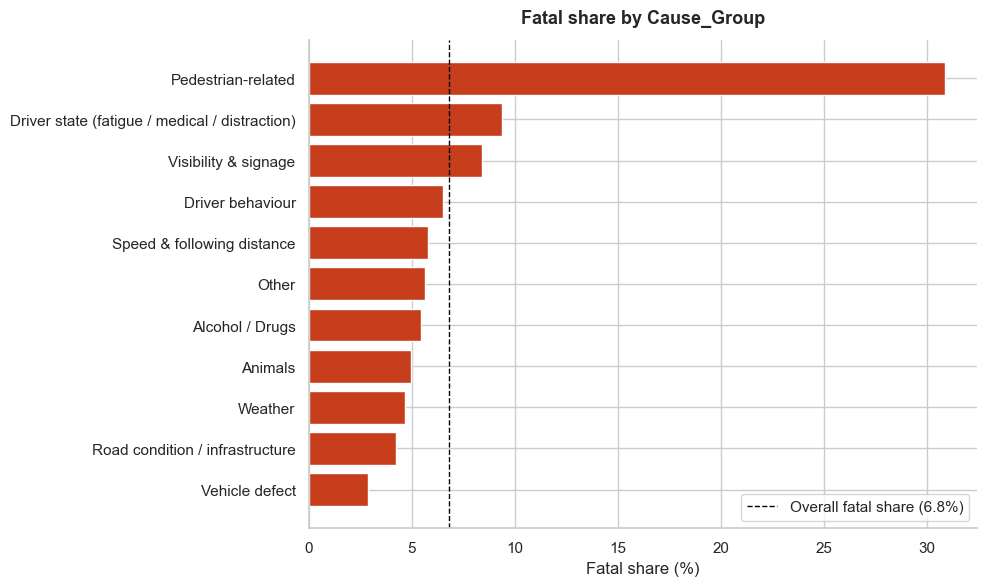

In [317]:
profile = cause_profile.sort_values('fatal_share')

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(profile.index, profile['fatal_share'] * 100, color=PALETTE['danger'])
ax.axvline(6.8, color='black', linestyle='--', linewidth=1, label='Overall fatal share (6.8%)')

ax.set_xlabel('Fatal share (%)')
ax.set_title('Fatal share by Cause_Group')
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

Based on the results. There were only 14,567 accidents involving pedestrians, but the fatal share is aproximatelly 31%. Alcohol/Drugs are under the fatality index, which is interesting, because one could expect it to be the main cause of death based on that.  

### 9.7 · `Ignored` field exploration

In [318]:
df[['Ignored', 'Deaths', 'Uninjured', 'Vehicles_Involved']].corr().round(3)

,Ignored,Deaths,Uninjured,Vehicles_Involved
Ignored,1.000,0.081,-0.069,0.094
Deaths,0.081,1.000,-0.015,0.049
Uninjured,-0.069,-0.015,1.000,0.441
Vehicles_Involved,0.094,0.049,0.441,1.000


Weak correlation

In [319]:
ignored_when_present = df[df['Ignored'] > 0].groupby('State')['Ignored'].mean().sort_values(ascending=False)
ignored_overall      = df.groupby('State')['Ignored'].mean().sort_values(ascending=False)

print('Avg Ignored when at least one is present:')
print(ignored_when_present.head(5).round(3).to_string())
print('\nOverall Ignored rate per State (top 5):')
print(ignored_overall.head(5).round(3).to_string())

Avg Ignored when at least one is present:
State
AM   1.436
AP   1.260
RR   1.246
RO   1.244
AC   1.239

Overall Ignored rate per State (top 5):
State
AM   0.290
PB   0.229
RR   0.219
PA   0.211
AP   0.209


The Ignored column includes individuals whose injuries were most likely not reported. The ignored records are concentrated in the north and northeast, which are the macro-regions with the highest fatality share.

In [320]:
fatal = df[df['Victims_Condition'] == 'With dead victims']
top_roads = fatal['Road_ID'].value_counts().head(10)
print(top_roads)

Road_ID
116.000    4097
101.000    3820
153.000    1394
381.000    1140
40.000     1099
316.000    1087
364.000    1029
163.000     982
230.000     842
277.000     838
Name: count, dtype: int64


Road with dead victims accident

In [321]:
top_roads_all = df['Road_ID'].value_counts().head(10)
print(top_roads_all)

Road_ID
101.000    76539
116.000    68812
381.000    22978
40.000     21990
153.000    18271
364.000    15354
163.000    14847
277.000    13631
376.000    12876
262.000    12254
Name: count, dtype: int64


Road with accidents overall

---
## 10 · Outliers

IQR-based outlier counts for each numeric column, plus a coordinate check.

In [322]:
def iqr_outliers(df, col):
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    return df[(df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)]

count_cols = ['People','Deaths','Slightly_Injured','Severely_Injured',
              'Uninjured','Ignored','Total_Injured','Vehicles_Involved','Road_Km']

rows = [(c, len(iqr_outliers(df, c)),
         len(iqr_outliers(df, c)) / len(df)) for c in count_cols]

print(f"{'Column':<20} {'Outliers':>10}   {'Share':>7}")
print('-' * 42)
for c, n, s in rows:
    print(f"{c:<20} {n:>10,}   {s:>6.1%}")

# Coordinate sanity
invalid = df[((df['Latitude'].abs() < 0.01) | (df['Longitude'].abs() < 0.01) |
              (df['Latitude'].abs() > 90)   | (df['Longitude'].abs() > 180))]
print(f"\nInvalid / suspicious coordinates: {len(invalid):,}")

# Drop them (keep only valid coordinates)
df = df[~((df['Latitude'].abs() < 0.01) | (df['Longitude'].abs() < 0.01) |
          (df['Latitude'].abs() > 90)   | (df['Longitude'].abs() > 180))]

print(f"After dropping: {len(df):,} valid records remain")

Column                 Outliers     Share
------------------------------------------
People                    8,586     1.9%
Deaths                   31,344     6.8%
Slightly_Injured         20,283     4.4%
Severely_Injured         96,750    20.9%
Uninjured                37,195     8.0%
Ignored                  57,240    12.4%
Total_Injured            30,484     6.6%
Vehicles_Involved         8,573     1.9%
Road_Km                   4,356     0.9%

Invalid / suspicious coordinates: 50
After dropping: 463,083 valid records remain


Outliers are not data errors. They are rare ,but valid accident outcomes (Deaths = 6.8%). Only invalid coordinates were removed. 

---
## 11 · Final clean dataset

In [323]:
# Drop columns
df = df.drop(columns=[
    # Outcome / leakage — only known after the accident is resolved
    'Deaths', 'Slightly_Injured', 'Severely_Injured',
    'Uninjured', 'Total_Injured', 'Ignored', 'People',
    # Redundant or replaced
    'Accident_Cause',   # replaced by Cause_Group
    'Day',              # raw day name, replaced by Weekday
    'Derived_Day',      # only used as a sanity check vs Day
    'Is_Weekend',       # redundant with Day_Type
    # High cardinality, non-predictive
    'City', 'Police_Station',
], errors='ignore')
print(df.columns.tolist())
print(f"Remaining columns ({df.shape[1]}):")

['Datetime', 'State', 'Road_ID', 'Road_Km', 'Accident_Type', 'Victims_Condition', 'Day_Phase', 'Km_Direction', 'Weather_Condition', 'Road_Type', 'Road_Delineation', 'Vehicles_Involved', 'Latitude', 'Longitude', 'Regional', 'Missing_Police_Station', 'Missing_Road_Data', 'Cause_Group', 'Hour', 'Month', 'Weekday', 'Day_Type', 'Region_BR', 'Time_Period']
Remaining columns (24):


In [324]:
display(df)

,Datetime,State,Road_ID,Road_Km,Accident_Type,Victims_Condition,Day_Phase,Km_Direction,Weather_Condition,Road_Type,Road_Delineation,Vehicles_Involved,Latitude,Longitude,Regional,Missing_Police_Station,Missing_Road_Data,Cause_Group,Hour,Month,Weekday,Day_Type,Region_BR,Time_Period
0,2017-01-01 01:45:00,RS,116.000,34.900,Rear-end collision,With injured victims,Night,Decreasing,Clear sky,Simple,Straight,2,-28.507,-50.941,SPRF-RS,False,False,Vehicle defect,1,1,Sunday,Sunday,South,Night
1,2017-01-01 01:00:00,PR,376.000,636.000,Run-off-road,With dead victims,Night,Increasing,Drizzle,Double,Curve,2,-25.754,-49.127,SPRF-PR,False,False,Speed & following distance,1,1,Sunday,Sunday,South,Night
2,2017-01-01 04:40:00,BA,101.000,65.000,Head-on collision,With dead victims,Sunrise,Decreasing,Cloudy,Simple,Curve,2,-11.962,-38.095,SPRF-BA,False,False,Driver state (fatigue / medical / distraction),4,1,Sunday,Sunday,Northeast,Night
3,2017-01-01 06:30:00,PA,316.000,72.500,Side impact collision,With dead victims,Sunrise,Decreasing,Clear sky,Simple,Straight,3,-1.290,-47.835,SPRF-PA,False,False,Driver behaviour,6,1,Sunday,Sunday,North,Morning
4,2017-01-01 09:00:00,GO,20.000,220.500,Collision with fixed object,With injured victims,Day,Decreasing,Clear sky,Simple,Temporary Detour,1,-14.142,-46.323,SPRF-DF,False,False,Road condition / infrastructure,9,1,Sunday,Sunday,Centre-West,Morning
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
463128,2023-02-09 05:10:00,PR,116.000,89.500,Collision with object,With injured victims,Night,Increasing,Clear sky,Double,Straight,1,-25.454,-49.088,SPRF-PR,False,False,Driver behaviour,5,2,Thursday,Weekday,South,Morning
463129,2023-06-28 19:48:00,ES,101.000,271.000,Broadside collision,With injured victims,Night,Increasing,Clear sky,Double,Straight,2,-20.233,-40.277,SPRF-ES,False,False,Driver behaviour,19,6,Wednesday,Weekday,Southeast,Evening
463130,2023-07-27 05:20:00,PI,343.000,478.000,Animal collision,With injured victims,Night,Decreasing,Clear sky,Simple,Curve,1,-6.153,-42.713,SPRF-PI,False,False,Animals,5,7,Thursday,Weekday,Northeast,Morning
463131,2023-05-13 09:10:00,RJ,116.000,173.000,Fall of vehicle occupant,With injured victims,Day,Decreasing,Clear sky,Double,Straight,3,-22.798,-43.357,SPRF-RJ,False,False,Pedestrian-related,9,5,Saturday,Saturday,Southeast,Morning
